----
## <font color='CornflowerBlue'>Practical 3: Neural networks with graphs and sequences</font> 
##### Alok Bharadwaj and Arjen Jakobi
---

In [1]:
# # Import functions 
# import os
# import re
# import graphein

# from graphein.protein.config import ProteinGraphConfig
# from graphein.protein.graphs import construct_graph
# from graphein.protein.visualisation import plotly_protein_structure_graph

# import pandas as pd
# # from Bio import PDB
# import numpy as np
# from sklearn.model_selection import train_test_split
# import matplotlib.pyplot as plt

# import networkx as nx
# from networkx import to_networkx_graph
# import torch
# import torch.nn as nn
# from torch_geometric.utils import from_networkx
# from torch_geometric.data import Data
# from torch_geometric.loader import DataLoader
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
# import biographs as bg
# import Bio.PDB
# from biopandas.pdb import PandasPdb

# 1. Protein structures and graphs

## How do proteins fold? 

-  Discussion on protein folding and the importance of understanding it. 
-  Show a simple example of a protein sequence and its corresponding 3D structure.

## Representing proteins as graphs

-  Explain how proteins can be represented as graphs
-  What level of detail do we want to capture? (e.g., atomic level, residue level, etc.)

Suppose we want to show residue level representation.

What do the following terms mean in the context of protein graphs?
- Nodes: __?_ answer: Residues (amino acids)
- Edges: __?_ answer: peptide bonds, hydrogen bonds, van der Waals interactions, etc.
- Node features: __?_ answer: properties of amino acids (e.g., hydrophobicity, charge, etc.), one-hot encoding of amino acid type, etc.
- Edge features: __?_ answer: distance between residues, etc.
- Graph-level features: __?_ answer: overall properties of the protein (e.g., molecular weight, dynamic properties, etc.)


Types of problems we can solve with protein graphs:
- Predict whether a protein is soluble or not.
- Predict binding affinity of a protein to a ligand.




## Visualization of protein structures and graphs

In [2]:
import graphein.protein as gp
from graphein.protein.graphs import construct_graph

params_1 = {
    "granularity": "CA",
    "edge_construction_functions": [
        gp.add_peptide_bonds,
    ],
}

config_1 = gp.ProteinGraphConfig(**params_1)

protein_graph_1 = construct_graph(config=config_1, path='1L2Y.pdb')




Output()

In [3]:
from src.utils import display_protein_with_graph
display_protein_with_graph(protein_graph_1)

# 2. Operations on graphs

## Visualising permutation invariance and equivariance

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
# Helper function to plot the graph and its adjacency matrix
def plot_graph_and_matrix(G, pos, ax_graph, ax_matrix, title):
    # Plot the graph
    nx.draw(G, pos, with_labels=True, node_color='lightblue', ax=ax_graph)
    ax_graph.set_title(title)

    # Get the adjacency matrix
    adj_matrix = nx.adjacency_matrix(G).todense()

      # Create a lighter colormap based on Blues
    cmap = LinearSegmentedColormap.from_list("lighter_blues", ["#ffffff", "#cce5ff", "#6699cc"])

    # Plot the adjacency matrix
    ax_matrix.matshow(adj_matrix, cmap=cmap)
    for (i, j), val in np.ndenumerate(adj_matrix):
        ax_matrix.text(j, i, f'{val}', ha='center', va='center', color='black')
    ax_matrix.set_xticks([])
    ax_matrix.set_yticks([])

# Function to apply permutation and plot
def apply_permutation_and_plot(permutation_func, permutation_type, title):
    # Original graph
    G = nx.Graph()
    G.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 0)])

    # Positions for original graph
    pos = nx.circular_layout(G)

    # Get og adjacency matrix
    adj_matrix = nx.adjacency_matrix(G).todense()


    # Apply permutation
    if permutation_type == "invariance":
        permuted_matrix = permutation_func(adj_matrix)
        G_permuted = nx.from_numpy_array(permuted_matrix)
        pos_permuted = pos
        equation = r"f(PX) = f(X)"
    elif permutation_type == "equivariance":
        permuted_matrix = permutation_func(adj_matrix)
        G_permuted = nx.from_numpy_array(permuted_matrix)
        pos_permuted = pos
        equation = r"f(PX) = Pf(X)"
    elif permutation_type == "unknown":
        permuted_matrix = permutation_func(adj_matrix)
        G_permuted = nx.from_numpy_array(permuted_matrix)
        pos_permuted = pos
        equation = r"???"
    else:
        raise ValueError("Permutation type must be 'invariance', 'equivariance', or 'unknown'.")


    # Plot results
    fig, axes = plt.subplots(1, 5, figsize=(8, 4))

    # Plot original graph and matrix
    plot_graph_and_matrix(G, pos, axes[0], axes[1], "Original Graph & Matrix")

    # Plot arrow with the equation
    axes[2].annotate("", xy=(1, 0.5), xytext=(0, 0.5), arrowprops=dict(arrowstyle="->", lw=2))
    axes[2].text(0.5, 0.6, equation, ha="center", fontsize=12)
    axes[2].axis('off')

    # Plot permuted graph and matrix
    plot_graph_and_matrix(G_permuted, pos_permuted, axes[3], axes[4], f"Permuted Graph & Matrix ({title})")

    plt.tight_layout()
    plt.show()


# Invariant permutation function
def invariant_permutation(adj_matrix):
    """
    This function applies a permutation to simulate permutation invariance.
    The permutation does not change the adjacency matrix, reflecting invariance.
    """
    # No change to the adjacency matrix (invariant)
    return adj_matrix

# Equivariant permutation function
def equivariant_permutation(adj_matrix):
    """
    This function applies a permutation that simulates permutation equivariance.
    The permutation matrix P is applied to the adjacency matrix to reflect equivariance.
    """
    # Define the permutation matrix P for swapping nodes
    perm = [2, 0, 3, 1]  # Example permutation used in the original code
    P = np.eye(4, dtype=int)[perm]

    # Apply the permutation: P * adj_matrix * P.T and cast result to integers
    return (P @ adj_matrix @ P.T).astype(int)

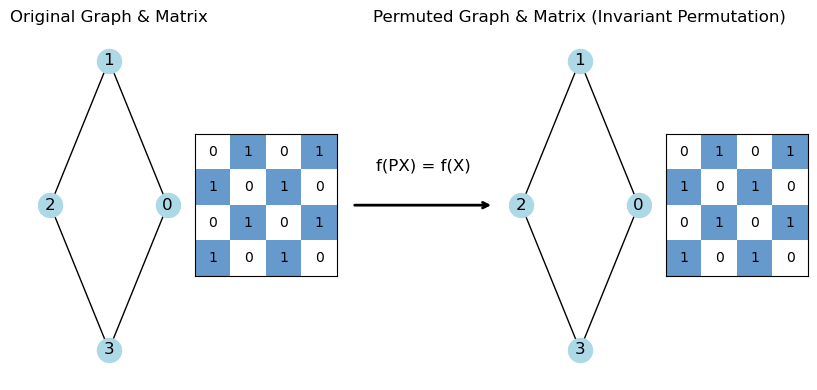

In [5]:
apply_permutation_and_plot(invariant_permutation, "invariance", "Invariant Permutation")

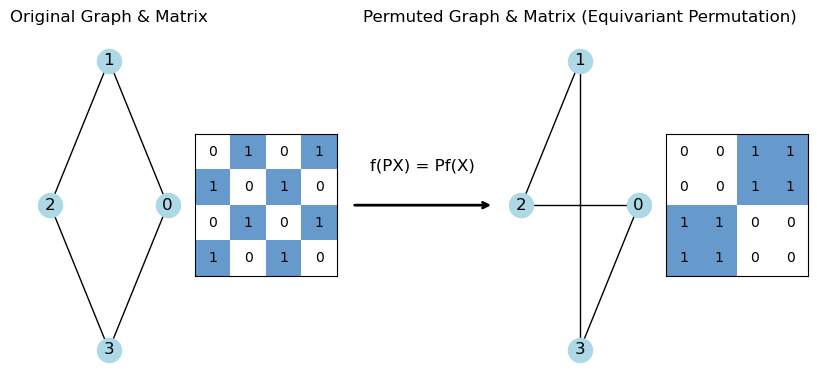

In [6]:
apply_permutation_and_plot(equivariant_permutation, "equivariance", "Equivariant Permutation")

Create your own permutation function and check if it is invariant or equivariant.

In [17]:
def identity_permutation(adj_matrix):
    return adj_matrix

def reverse_permutation(adj_matrix):
    P = np.array([[0, 0, 0, 1],
                  [0, 0, 1, 0],
                  [0, 1, 0, 0],
                  [1, 0, 0, 0]])
    return P @ adj_matrix @ P.T

def swap_permutation(adj_matrix):
    P = np.array([[0, 1, 0, 0],
                  [1, 0, 0, 0],
                  [0, 0, 1, 0],
                  [0, 0, 0, 1]])
    return P @ adj_matrix @ P.T

def custom_permutation(adj_matrix):
    # create a custom permutation. 
    # each 
    P = np.array([[0, 1, 0, 1],
                  [1, 0, 0, 0],
                  [0, 0, 1, 0],
                  [1, 0, 0, 1]])
    return P @ adj_matrix @ P.T


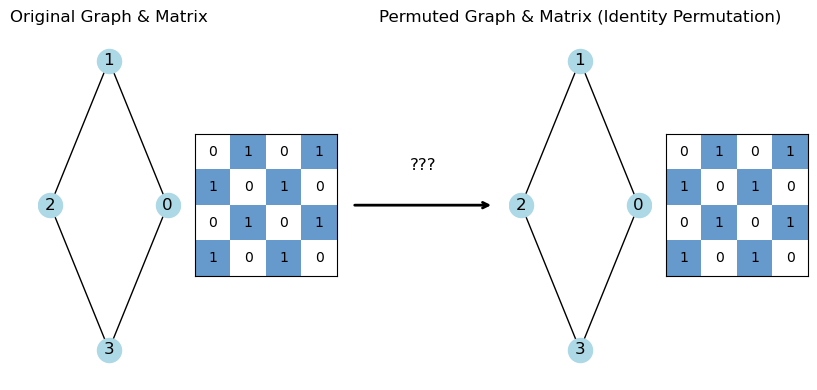

In [8]:
apply_permutation_and_plot(identity_permutation, "unknown", "Identity Permutation")

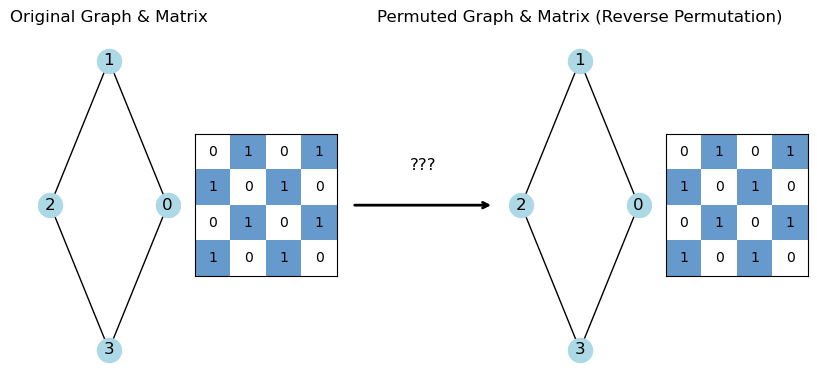

In [9]:
apply_permutation_and_plot(reverse_permutation, "unknown", "Reverse Permutation")

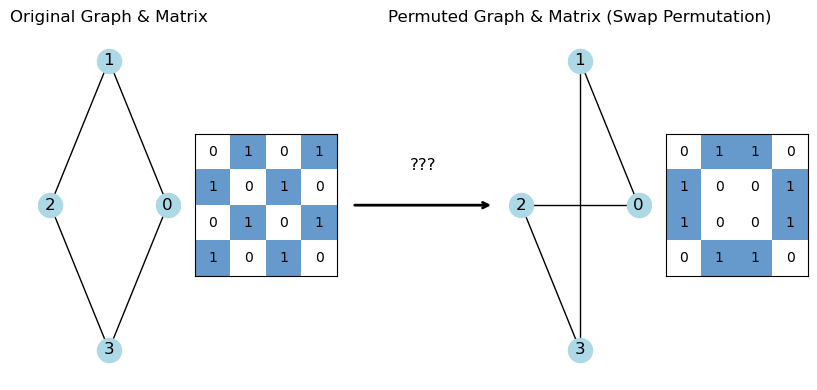

In [10]:
apply_permutation_and_plot(swap_permutation, "unknown", "Swap Permutation")

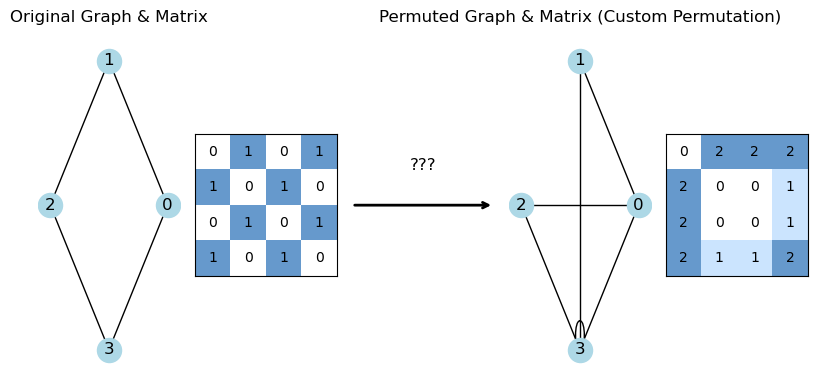

In [18]:
apply_permutation_and_plot(custom_permutation, "unknown", "Custom Permutation")

# 3. Graph Convolutional Networks (GCN)


## Understanding Message Passing

### Play a simple game with your neighbor! 

- Each of you has a feature: three numbers which represent the following aspects about you: 
 1) Did you like cats or dogs? (1 for cats, 0 for dogs)
 2) What was the digit that you drew for last week's MNIST assignment? (0-9)
 3) What are the chances that you think it will rain tomorrow? (0-1)
 
Create your feature vector


In [19]:
your_node_id = 0 # 
your_feature_vector = [1, 4, 0.78]


Update your feature vector in the Google Sheet document next to your node id

Google Sheet link: ____ 


Message passing step:
- You will then collect the feature vectors from all your neighbors (next to you in all directions) and compute a new feature vector for yourself by taking the average of your neighbors' feature vectors.
- You will share your vector with your neighbors

In [21]:
# Uncomment and modify the following lines to define your neighbors and their features
your_neighbors_features = [
    [0, 2, 0.5],  # Neighbor 1
    [1, 3, 0.9],  # Neighbor 2
]

Aggregation step:
- You will then take the average of the feature vectors you received from your neighbors and update your own feature vector with this new information.

In [22]:
neighbors_feature_matrix = np.array(your_neighbors_features)
your_new_feature_vector = np.mean(neighbors_feature_matrix, axis=0)
print("Your original feature vector:", your_feature_vector)
print("Your new feature vector after aggregation:", your_new_feature_vector)


Your original feature vector: [1, 4, 0.78]
Your new feature vector after aggregation: [0.5 2.5 0.7]


Note in this step you did now use any weight while aggregating the information from your neighbors. You also did not normalise the information. This is a simple example of a message passing step in a GCN. In practice, we would use learnable weights and normalisation to improve the performance of the model.

Now, update your new feature vector in the Google Sheet document to see how the information propagates through the network.

That is it! 

# 4. Training GCN 

The actual update rule for a GCN layer is as follows:
\begin{equation}
\mathbf{h}_i^{(l+1)} = \sigma \left( \sum_{j \in \mathcal{N}(i)} \frac{1}{\sqrt{d_i d_j}} \mathbf{W}^{(l)} \mathbf{h}_j^{(l)} \right)
\end{equation}

Where:
- $\mathbf{h}_i^{(l)}$ is the feature vector of node $i$ at layer $l$. Shape = ($d_{in}$, 1)
- $\mathcal{N}(i)$ is the set of neighbors of node $i$
- $d_i$ is the degree of node $i$
- $\mathbf{W}^{(l)}$ is the weight matrix for layer $l$. Shape = ($d_{out}$, $d_{in}$)
- $\sigma$ is the activation function (e.g., ReLU)



Note that the weight matrix $\mathbf{W}^{(l)}$ is learnable. This will be shared across all nodes in the graph, which allows the model to learn a generalizable representation of the graph structure.

In [24]:
import torch
import torch.nn as nn

# Implement your own Graph Convolutional Layer using the update rule given above

class CustomGCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super(CustomGCNLayer, self).__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        # x: [num_nodes, in_features]
        # adj: [num_nodes, num_nodes]
        # Aggregate neighbor features
        neighbor_agg = torch.matmul(adj, x)  # [num_nodes, in_features]
        # Apply linear transformation
        out = self.linear(neighbor_agg)  # [num_nodes, out_features]
        return out

In [28]:
# Example usage
num_nodes = 6
in_features = 3
out_features = 1
# Create random node features and adjacency matrix
node_features = torch.rand(num_nodes, in_features)
adjacency_matrix = torch.rand(num_nodes, num_nodes)
gcn_layer = CustomGCNLayer(in_features, out_features)
output_features = gcn_layer(node_features, adjacency_matrix)
print(f"Input node features:\n{node_features}")
print(f"Output node features after GCN layer:\n{output_features}")


Input node features:
tensor([[0.8932, 0.5481, 0.0598],
        [0.6206, 0.0565, 0.0053],
        [0.6166, 0.6382, 0.2468],
        [0.1540, 0.9352, 0.5181],
        [0.7302, 0.9012, 0.3693],
        [0.3508, 0.3816, 0.8539]])
Output node features after GCN layer:
tensor([[ 0.0073],
        [ 0.1824],
        [ 0.0992],
        [-0.0185],
        [-0.0432],
        [ 0.0472]], grad_fn=<AddmmBackward0>)


# 5. Validation 